# Doohan trial to a flat LMDP

This notebook loads one recorded navigation trial, reduces it to entered maze towers, converts the session's Doohan edge-list maze into a discrete tower-state graph, and solves a flat goal-conditioned LMDP.

## 1. Setup paths and load the trial

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    raise FileNotFoundError("Run this notebook from the project or notebook directory")

sys.path.insert(0, str(PROJECT_ROOT / "src"))
from andrew_mlmdp import (  # noqa: E402
    LMDPEnvironment,
    load_doohan_maze,
    plotting as viz,
)

GRIDMAZE_ROOT = PROJECT_ROOT / "external" / "GridMaze-mFC-ephys-DATA"
GRIDMAZE_CODE = GRIDMAZE_ROOT / "code"
MAZE_CONFIG_PATH = GRIDMAZE_ROOT / "data/experiment_info/maze_configs.json"

SUBJECT_ID = "m2"
SESSION_NAME = "2022-06-23.maze"
TRIAL_ID = 10

sys.path.insert(0, str(GRIDMAZE_CODE))
from GridMaze.core.get_sessions import MazeSession

session = MazeSession(
    SUBJECT_ID,
    SESSION_NAME,
    with_data=["trajectories_df", "trial_info_df"],
    verbose=False,
)
trajectories = session.trajectories_df
trial_info = session.trial_info_df
if trajectories is None or trial_info is None:
    raise FileNotFoundError("required trajectory data is missing")

print(f"session: {session.name}")
print(f"maze: {session.maze_name}")
print(f"trial: {TRIAL_ID}")

session: m2.2022-06-23.maze
maze: maze_1
trial: 1


## 2. Extract the discrete tower trajectory

The tracking and trial tables share their row index. Consecutive repeated spatial labels are collapsed before bridge labels are removed, preserving genuine tower re-entries.

In [2]:
trial_mask = (
    (trial_info["trial"] == TRIAL_ID)
    & (trial_info["trial_phase"] == "navigation")
)
positions = trajectories.loc[
    trial_mask,
    ("maze_position", "simple"),
].dropna()
if positions.empty:
    raise ValueError(f"Trial {TRIAL_ID} has no navigation trajectory")

tower_positions = positions[
    ~positions.astype(str).str.contains("-", regex=False)
].astype(str)
entered_towers = tower_positions[
    tower_positions.ne(tower_positions.shift())
]
node_trajectory = entered_towers.tolist()
if not node_trajectory:
    raise ValueError(f"Trial {TRIAL_ID} has no tower-node trajectory")
goal_labels = trial_info.loc[trial_mask, "goal"].dropna().unique()
if len(goal_labels) != 1:
    raise ValueError("The selected trial must have exactly one goal")

start_label = node_trajectory[0]
goal_label = str(goal_labels[0])
print(" -> ".join(node_trajectory))
print(f"start: {start_label} | goal: {goal_label}")

A2 -> B2 -> C2 -> D2 -> E2 -> F2 -> F3 -> E3 -> D3 -> D4 -> D5 -> E5 -> F5 -> G5 -> G4 -> G3 -> G2 -> G1 -> G2 -> G3 -> G4 -> G5 -> G6 -> G7
start: A2 | goal: G7


## 3. Convert the Doohan maze into an LMDP environment

In [3]:
definition = load_doohan_maze(session.maze_name, MAZE_CONFIG_PATH)
maze = definition.maze
start = definition.coordinate_for(start_label)
goal = definition.coordinate_for(goal_label)
environment = LMDPEnvironment(maze)

print(f"tower grid shape: {maze.shape}")
print(f"physical states: {len(maze.free_cells)}")
print(f"start coordinate: {start}")
print(f"goal coordinate: {goal}")

tower grid shape: (7, 7)
physical states: 49
start coordinate: (5, 0)
goal coordinate: (0, 6)


## 4. Plot the discrete maze

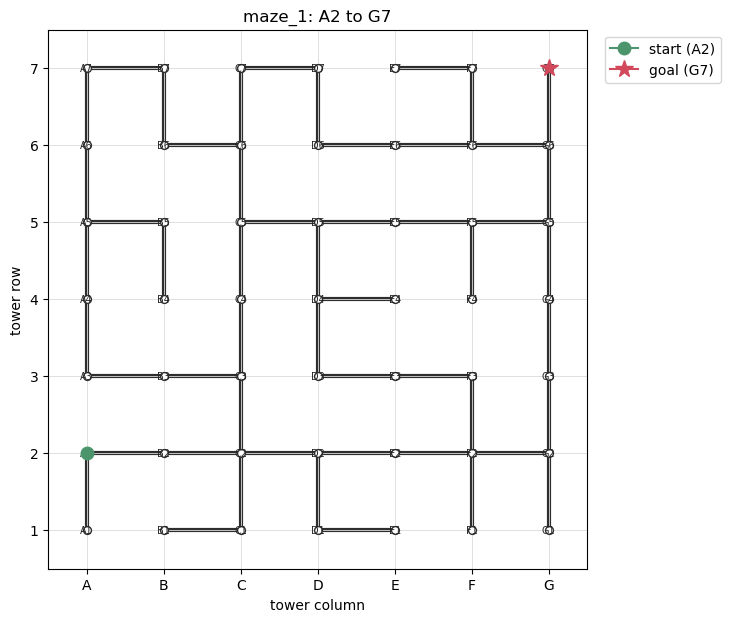

In [4]:
tower_labels = dict(definition.label_by_coordinate)
ax = viz.plot_maze(
    maze,
    labels=tower_labels,
    title=f"{session.maze_name}: {start_label} to {goal_label}",
)
ax.plot(
    start[1],
    start[0],
    marker="o",
    color="#4c956c",
    markersize=9,
    label=f"start ({start_label})",
)
ax.plot(
    goal[1],
    goal[0],
    marker="*",
    color="#d1495b",
    markersize=13,
    label=f"goal ({goal_label})",
)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.show()

## 5. Score the behavior and plot flat-LMDP desirability

The movement log-likelihood uses natural logarithms and conditions on leaving each tower. It scores the collapsed tower-entry sequence, not frame-by-frame tracking samples.

observed transitions: 23
total log-likelihood under flat LMDP policy: -29.519903
mean log-likelihood per transition: -1.283474


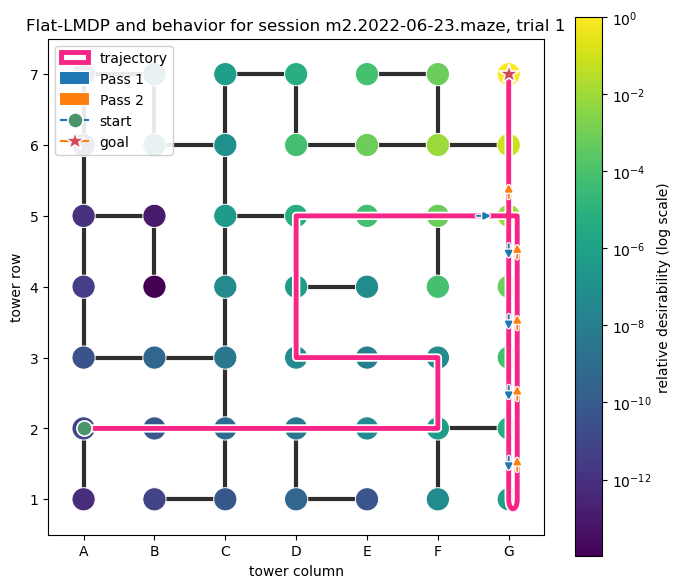

In [10]:
solution = environment.solve_flat(goal)
observed_trajectory = [
    definition.coordinate_for(label) for label in node_trajectory
]
number_of_transitions = len(observed_trajectory) - 1
movement_log_likelihood = solution.movement_log_likelihood(observed_trajectory)
print(f"observed transitions: {number_of_transitions}")
print(f"total log-likelihood under flat LMDP policy: {movement_log_likelihood:.6f}")
if number_of_transitions:
    mean_log_likelihood = movement_log_likelihood / number_of_transitions
    print(f"mean log-likelihood per transition: {mean_log_likelihood:.6f}")
else:
    print("mean log-likelihood per transition: n/a")

goal_state = maze.state_index(goal)
relative_desirability = (
    solution.desirability / solution.desirability[goal_state]
)
positive = relative_desirability[relative_desirability > 0.0]
rows = [coordinate[0] for coordinate in maze.free_cells]
columns = [coordinate[1] for coordinate in maze.free_cells]

fig, ax = plt.subplots(figsize=(8, 7))
viz.plot_maze(maze, show_grid=False, title=None, ax=ax)
image = ax.scatter(
    columns,
    rows,
    c=relative_desirability,
    cmap="viridis",
    norm=LogNorm(vmin=positive.min(), vmax=1.0),
    s=280,
    edgecolor="white",
    linewidth=0.7,
    zorder=2,
)
viz.plot_trajectory_overlay(
    maze,
    observed_trajectory,
    goal=goal,
    ax=ax,
)
ax.legend(loc="upper left", framealpha=0.9)
ax.set_title(f"Flat-LMDP and behavior for session {session.name}, trial {TRIAL_ID}")
fig.colorbar(image, ax=ax, label="relative desirability (log scale)")
plt.show()